<a href="https://colab.research.google.com/github/Sreenikesh-A/Medical_Image_Lung_Segmentation/blob/main/Med_Image_Segmentation_lung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lung Segmentation from Chest X-Ray Using U-Net**



# **RUN INSTRUCTIONS**
1.Change runtype to GPU(Runtime->change runtime type->GPU)

2.Scroll down and RUN ONLY The "Model Verify" block(last block)

3.it asks to Upload File

4.Upload An X-ray Image of chest

5.The Segmentation report is generated

6.My Trained Model is uploaded in drive , which will be acessed by the code

Drive link for my trained model if needed:https://drive.google.com/file/d/1buFyM65kLIBt1RptLdurJqLeqYwhsxKp/view?usp=sharing

DATASET LINK :https://www.kaggle.com/datasets/iamtapendu/chest-x-ray-lungs-segmentation


**Problem Statement :** Build a computer vision system that identifies and segments a target biological or medical structure in an image. The output should be a segmentation mask and should be evaluated using appropriate metrics such as IoU or Dice score. This is an AI segmentation benchmark and not a clinical diagnostic system. Teams should add a meaningful novel feature.

**Objectives:**

* Segment the lungs from chest X-ray images.
* Evaluate the segmentation using Dice Score and IoU.
* Visualize the predicted segmentation mask.
* Novel feature - Quantitative Lung Region Analysis and Boundary Visualization

**Approach**

 We decided to take lungs because of the availability of the dataset in kaggle and because it is a relatively easy organ to train than complex parts and doesn't take a lot of GPU .conclusion of novel feature is obtained from asking chatgpt "what is novel feature",and we thought of calculating the area and representing the boundary of the lungs and such

**Dataset**

Chest X-Ray Lungs Segmentation

* Number of images: 704
* Number of corresponding masks: 704
* Dataset source: Kaggle
* Dataset Description: A collection of 704 chest X-ray images with corresponding lung segmentation masks, derived from the Montgomery County and Shenzhen Chest X-ray databases. Although the source dataset contains tuberculosis-related clinical information, this project uses only the chest X-ray images and their corresponding lung masks for the lung segmentation task. TB labels and demographic metadata are not used by the segmentation model.













# **Project pipeline**

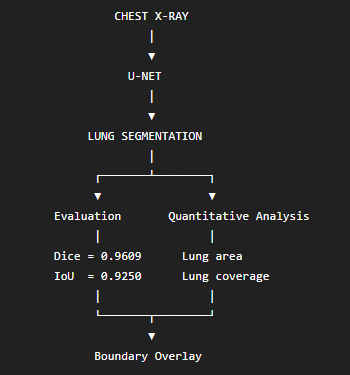

In [ ]:
!pip install -q -U kaggle

In [ ]:
import os
from getpass import getpass

token = getpass("Enter your Kaggle API token: ")
os.environ["KAGGLE_API_TOKEN"] = token

Enter your Kaggle API token: ··········


In [ ]:
!kaggle datasets list -s "chest xray lung segmentation"

ref                                                                   title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
farhanhaikhan/unet-lung-segmentation-dataset-siim-covid               UNET Lung Segmentation Dataset SIIM COVID             311202594  2021-05-19 18:43:19.720000           1492         42                1  
farhanhaikhan/unet-lung-segmentation-weights-for-chest-x-rays         UNET Lung Segmentation Weights for Chest X Rays        28575642  2026-09-20 11:16:47.230000           1005         51            0.875  
azkihimmawan/chest-xray-masks-and-defect-detection                    Chest X-Ray Masks and Defect Detection               3345325826  2020-12-22 10:20:25.470000           

In [ ]:
!kaggle datasets download -d iamtapendu/chest-x-ray-lungs-segmentation

Dataset URL: https://www.kaggle.com/datasets/iamtapendu/chest-x-ray-lungs-segmentation
License(s): apache-2.0
chest-x-ray-lungs-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q chest-x-ray-lungs-segmentation.zip -d dataset

replace dataset/Chest-X-Ray/Chest-X-Ray/image/1000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root, len(files))

dataset 1
dataset/Chest-X-Ray 0
dataset/Chest-X-Ray/Chest-X-Ray 0
dataset/Chest-X-Ray/Chest-X-Ray/mask 704
dataset/Chest-X-Ray/Chest-X-Ray/image 704


In [ ]:
IMAGE_DIR = "dataset/Chest-X-Ray/Chest-X-Ray/image"
MASK_DIR = "dataset/Chest-X-Ray/Chest-X-Ray/mask"

print("Images:", IMAGE_DIR)
print("Masks :", MASK_DIR)

Images: dataset/Chest-X-Ray/Chest-X-Ray/image
Masks : dataset/Chest-X-Ray/Chest-X-Ray/mask


Number of images: 704
Number of masks: 704


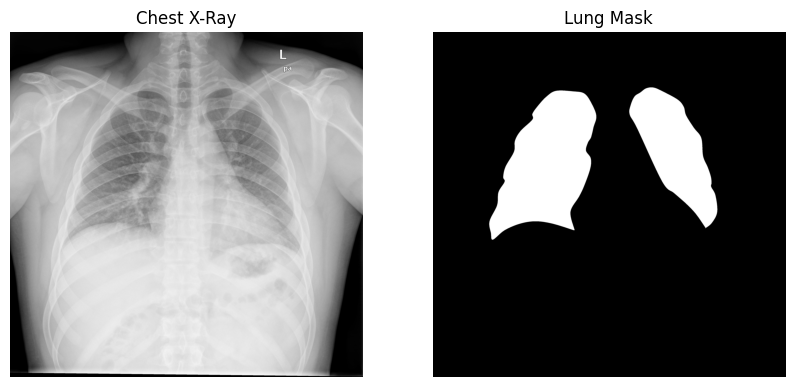

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_files = os.listdir(IMAGE_DIR)
mask_files = os.listdir(MASK_DIR)

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

# Take the first image
image_path = os.path.join(IMAGE_DIR, image_files[0])
mask_path = os.path.join(MASK_DIR, mask_files[0])

image = Image.open(image_path)
mask = Image.open(mask_path)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Chest X-Ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Lung Mask")
plt.axis("off")

plt.show()

In [ ]:
print("First 10 image files:")
print(image_files[:10])

print("\nFirst 10 mask files:")
print(mask_files[:10])

First 10 image files:
['1321.png', '1687.png', '1666.png', '1633.png', '1149.png', '1243.png', '1349.png', '1262.png', '1393.png', '1056.png']

First 10 mask files:
['1321.png', '1687.png', '1666.png', '1633.png', '1149.png', '1243.png', '1349.png', '1262.png', '1393.png', '1056.png']


In [ ]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

class LungDataset(Dataset):

    def __init__(self, image_dir, mask_dir, filenames, image_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.image_size = image_size

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        filename = self.filenames[idx]

        # Load image
        image_path = os.path.join(self.image_dir, filename)
        image = Image.open(image_path).convert("L")
        image = image.resize(
            (self.image_size, self.image_size)
        )

        # Load mask
        mask_path = os.path.join(self.mask_dir, filename)
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize(
            (self.image_size, self.image_size)
        )

        # Convert to NumPy
        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.float32) / 255.0

        # Make mask binary
        mask = (mask > 0.5).astype(np.float32)

        # Add channel dimension
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        # Convert to PyTorch tensors
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [ ]:
from sklearn.model_selection import train_test_split

# Get filenames that exist in both folders
filenames = sorted(
    list(set(os.listdir(IMAGE_DIR)) & set(os.listdir(MASK_DIR)))
)

print("Total matched images:", len(filenames))

# 70% training, 30% temporary
train_files, temp_files = train_test_split(
    filenames,
    test_size=0.30,
    random_state=42
)

# Split temporary into 15% validation and 15% test
val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42
)

print("Training:", len(train_files))
print("Validation:", len(val_files))
print("Testing:", len(test_files))

Total matched images: 704
Training: 492
Validation: 106
Testing: 106


In [ ]:
train_dataset = LungDataset(
    IMAGE_DIR,
    MASK_DIR,
    train_files
)

val_dataset = LungDataset(
    IMAGE_DIR,
    MASK_DIR,
    val_files
)

test_dataset = LungDataset(
    IMAGE_DIR,
    MASK_DIR,
    test_files
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 492
Validation dataset: 106
Test dataset: 106


In [ ]:
image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape :", mask.shape)
print("Image min  :", image.min().item())
print("Image max  :", image.max().item())
print("Mask values:", torch.unique(mask))

Image shape: torch.Size([1, 256, 256])
Mask shape : torch.Size([1, 256, 256])
Image min  : 0.0
Image max  : 1.0
Mask values: tensor([0., 1.])


U-Net Model

In [ ]:
import torch
import torch.nn as nn


# Double Convolution Block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


# U-Net
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024, 512, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # Final output layer
        self.out = nn.Conv2d(
            64, 1, kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
model = UNet().to(device)
print("U-Net created successfully!")

test_input = torch.randn(1, 1, 256, 256).to(device)
with torch.no_grad():
    test_output = model(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)

U-Net created successfully!
Input shape : torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


**Dice Loss**

In [ ]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    intersection = (pred * target).sum()
    dice = ((2 * intersection + smooth)/(pred.sum() + target.sum() + smooth))
    return 1 - dice

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 62
Validation batches: 14
Test batches: 14


In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
print("Optimizer created successfully!")

Optimizer created successfully!


In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = dice_loss(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = dice_loss(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}")

Epoch [1/10] Train Loss: 0.3513 Val Loss: 0.3002
Epoch [2/10] Train Loss: 0.2539 Val Loss: 0.2452
Epoch [3/10] Train Loss: 0.2179 Val Loss: 0.2135
Epoch [4/10] Train Loss: 0.1942 Val Loss: 0.1886
Epoch [5/10] Train Loss: 0.1702 Val Loss: 0.1677
Epoch [6/10] Train Loss: 0.1526 Val Loss: 0.1512
Epoch [7/10] Train Loss: 0.1351 Val Loss: 0.1346
Epoch [8/10] Train Loss: 0.1210 Val Loss: 0.1230
Epoch [9/10] Train Loss: 0.1096 Val Loss: 0.1136
Epoch [10/10] Train Loss: 0.1001 Val Loss: 0.1026


In [ ]:
torch.save(
    model.state_dict(),
    "lung_segmentation_unet.pth")
print("Model saved successfully!")

Model saved successfully!


Dice Score & IoU

In [ ]:
def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    smooth = 1e-6
    intersection = (pred * target).sum()
    dice = ((2 * intersection + smooth)/(pred.sum() + target.sum() + smooth))
    return dice.item()

def iou_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    smooth = 1e-6
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

In [ ]:
model.eval()

total_dice = 0
total_iou = 0
num_batches = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)
        total_dice += dice_score(outputs, masks)
        total_iou += iou_score(outputs, masks)
        num_batches += 1

average_dice = total_dice / num_batches
average_iou = total_iou / num_batches

print(f"Test Dice Score: {average_dice:.4f}")
print(f"Test IoU Score : {average_iou:.4f}")

Test Dice Score: 0.9609
Test IoU Score : 0.9250


**AI Prediction - Segmentation Mask**

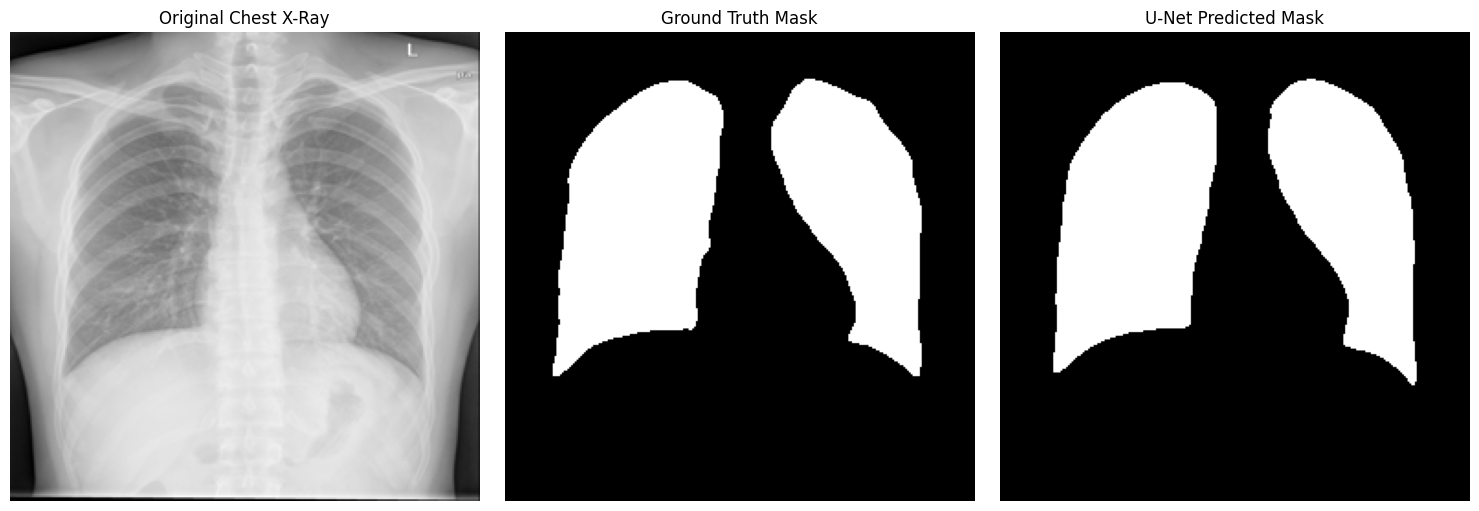

In [ ]:
import matplotlib.pyplot as plt

model.eval()

# Get one test image
image, mask = test_dataset[0]

# Add batch dimension and move to device
input_image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_image)

# Convert prediction to binary mask
prediction = torch.sigmoid(output)
prediction = (prediction > 0.5).float()

# Move to CPU
image_np = image.squeeze().numpy()
mask_np = mask.squeeze().numpy()
prediction_np = prediction.squeeze().cpu().numpy()

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap="gray")
plt.title("Original Chest X-Ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction_np, cmap="gray")
plt.title("U-Net Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

**Novel Feature**

In [ ]:
import cv2
import numpy as np

# Convert prediction to uint8
pred_mask = (prediction_np > 0.5).astype(np.uint8)

# Calculate lung area
lung_area_pixels = np.sum(pred_mask)

# Total image pixels
total_pixels = pred_mask.shape[0] * pred_mask.shape[1]

# Percentage of image occupied by predicted lungs
lung_percentage = (lung_area_pixels / total_pixels) * 100

print(f"Predicted Lung Area: {lung_area_pixels} pixels")
print(f"Lung Area Percentage: {lung_percentage:.2f}%")

Predicted Lung Area: 18027 pixels
Lung Area Percentage: 27.51%


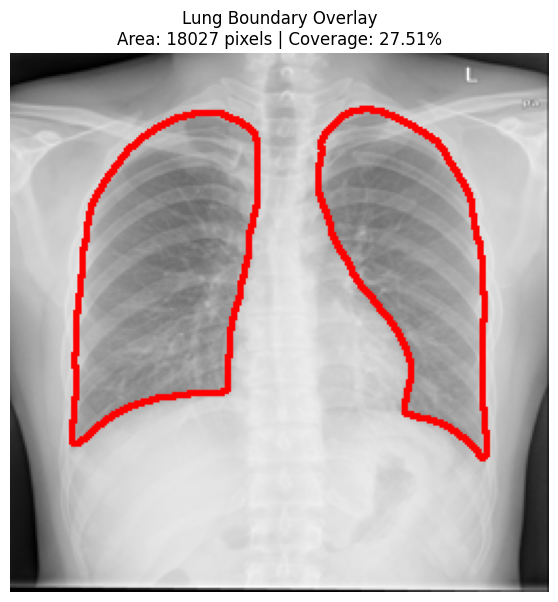

In [ ]:
# Find contours of predicted lung region
contours, _ = cv2.findContours(
    pred_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE)

# Convert X-ray to RGB
overlay = cv2.cvtColor((image_np * 255).astype(np.uint8),cv2.COLOR_GRAY2RGB)
# Draw predicted lung boundaries
cv2.drawContours(
    overlay,
    contours,
    -1,
     (255, 0, 0),2)

# Display
plt.figure(figsize=(7, 7))
plt.imshow(overlay)
plt.title(
    f"Lung Boundary Overlay\n"
    f"Area: {lung_area_pixels} pixels | "
    f"Coverage: {lung_percentage:.2f}%")

plt.axis("off")
plt.show()

In [ ]:
# Find connected components in the predicted lung mask
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    pred_mask,
    connectivity=8)

# Ignore background (label 0)
components = []

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    components.append((i, area, centroids[i]))

# Sort components by area
components = sorted(
    components,
    key=lambda x: x[1],
    reverse=True)

print("Detected lung regions:")

for i, (label, area, centroid) in enumerate(components[:5]):
    print(
        f"Region {i+1}: "
        f"{area} pixels, "
        f"centroid = ({centroid[0]:.1f}, {centroid[1]:.1f})")

Detected lung regions:
Region 1: 10039 pixels, centroid = (72.9, 101.6)
Region 2: 7988 pixels, centroid = (191.0, 96.8)


In [ ]:
# Take the two largest regions
largest_regions = components[:2]

if len(largest_regions) >= 2:

    region1 = largest_regions[0]
    region2 = largest_regions[1]

    area1 = region1[1]
    area2 = region2[1]

    x1 = region1[2][0]
    x2 = region2[2][0]

    # Determine left/right based on image position
    if x1 < x2:
        left_area = area1
        right_area = area2
    else:
        left_area = area2
        right_area = area1

    difference = abs(left_area - right_area)

    asymmetry_percentage = (
        difference /
        ((left_area + right_area) / 2)
    ) * 100

    print(f"Left lung area : {left_area} pixels")
    print(f"Right lung area: {right_area} pixels")
    print(f"Area difference: {difference} pixels")
    print(f"Area asymmetry: {asymmetry_percentage:.2f}%")

else:
    print("Could not identify two separate lung regions.")

Left lung area : 10039 pixels
Right lung area: 7988 pixels
Area difference: 2051 pixels
Area asymmetry: 22.75%


In [ ]:
from google.colab import files

files.download("lung_segmentation_unet.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **MODEL VERIFYY**

In [ ]:

!pip -q install gdown
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from PIL import Image
from google.colab import files

MODEL_PATH = "lung_segmentation_unet.pth"
MODEL_ID = "1buFyM65kLIBt1RptLdurJqLeqYwhsxKp"
if not os.path.exists(MODEL_PATH):

    print("Downloading trained U-Net model...")
    !gdown --id 1buFyM65kLIBt1RptLdurJqLeqYwhsxKp -O lung_segmentation_unet.pth
    print("✅ Trained model downloaded.")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

#U-NET

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.double_conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.double_conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        # Final segmentation layer
        self.out = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )


    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.out(d1)

#LOAD TRAINED MODEL

model = UNet().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✅ Trained U-Net loaded successfully.")
print()
print("=" * 60)
print("🫁 LUNG SEGMENTATION DEMONSTRATION")
print("=" * 60)
print()
print("Please upload a chest X-ray image.")
print()

uploaded = files.upload()

xray_filename = list(uploaded.keys())[0]

print()
print("✅ X-ray uploaded:", xray_filename)

#PREPROCESS X-RAY

xray = Image.open(
    xray_filename
).convert("L")

# Resize to model input size
xray_resized = xray.resize(
    (256, 256)
)

# Convert to NumPy
xray_np = np.array(
    xray_resized,
    dtype=np.float32
) / 255.0

# Convert to tensor
input_tensor = torch.tensor(
    xray_np,
    dtype=torch.float32
)

input_tensor = (
    input_tensor
    .unsqueeze(0)
    .unsqueeze(0)
    .to(device))

#RUN U-NET

print()
print("Running lung segmentation...")

with torch.no_grad():

    output = model(input_tensor)

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > 0.5
    ).float()


# Convert to NumPy
pred_mask = (
    predicted_mask
    .squeeze()
    .cpu()
    .numpy()
    .astype(np.uint8)
)

print("✅ Segmentation completed.")

#SHOW SEGMENTATION MASK

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    xray_np,
    cmap="gray"
)

plt.title(
    "Input Chest X-Ray"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    pred_mask,
    cmap="gray"
)

plt.title(
    "Predicted Lung Segmentation Mask"
)

plt.axis("off")

plt.tight_layout()

plt.show()

#NOVEL FEATURE:

lung_area = int(
    np.sum(pred_mask)
)

total_pixels = (
    pred_mask.shape[0] *
    pred_mask.shape[1]
)

lung_coverage = (
    lung_area /
    total_pixels
) * 100

#IDENTIFY LEFT/RIGHT LUNG REGIONS

num_labels, labels, stats, centroids = (
    cv2.connectedComponentsWithStats(
        pred_mask,
        connectivity=8
    )
)

components = []

for i in range(1, num_labels):

    area = stats[
        i,
        cv2.CC_STAT_AREA
    ]

    centroid = centroids[i]

    components.append(
        (
            i,
            area,
            centroid
        )
    )


# Largest regions first
components = sorted(
    components,
    key=lambda x: x[1],
    reverse=True
)


left_area = None
right_area = None
area_difference = None
area_asymmetry = None


if len(components) >= 2:

    region1 = components[0]
    region2 = components[1]

    area1 = region1[1]
    area2 = region2[1]

    x1 = region1[2][0]
    x2 = region2[2][0]

    if x1 < x2:

        left_area = area1
        right_area = area2

    else:

        left_area = area2
        right_area = area1

    area_difference = abs(
        left_area -
        right_area
    )

    average_area = (
        left_area +
        right_area
    ) / 2

    area_asymmetry = (
        area_difference /
        average_area
    ) * 100

#DISPLAY QUANTITATIVE RESULTS

print()
print("=" * 60)
print("📊 QUANTITATIVE LUNG REGION ANALYSIS")
print("=" * 60)

print(
    f"Total Lung Area : "
    f"{lung_area:,} pixels"
)

print(
    f"Lung Coverage   : "
    f"{lung_coverage:.2f}%"
)

if left_area is not None:

    print(
        f"Left Lung Area  : "
        f"{left_area:,} pixels"
    )

    print(
        f"Right Lung Area : "
        f"{right_area:,} pixels"
    )

    print(
        f"Area Difference : "
        f"{area_difference:,} pixels"
    )

    print(
        f"Area Asymmetry  : "
        f"{area_asymmetry:.2f}%"
    )

else:

    print(
        "Two separate lung regions "
        "could not be identified."
    )

print("=" * 60)


# ------------------------------------------------
# 14. CREATE BOUNDARY OVERLAY
# ------------------------------------------------

contours, _ = cv2.findContours(
    pred_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Convert X-ray to RGB
overlay = cv2.cvtColor(
    (xray_np * 255).astype(np.uint8),
    cv2.COLOR_GRAY2RGB
)

# Draw predicted lung boundaries
cv2.drawContours(
    overlay,
    contours,
    -1,
    (255, 0, 0),
    2
)

#NOVEL FEATURE IMAGE

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    "Novel Feature: Predicted Lung Boundary Overlay"
)

plt.axis("off")

plt.show()


Using device: cuda
✅ Trained U-Net loaded successfully.

🫁 LUNG SEGMENTATION DEMONSTRATION

Please upload a chest X-ray image.

